In [1]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
import h5py

def load_h5py_file(file_path):
    data = {
        'neural_features': [],
        'n_time_steps': [],
        'seq_class_ids': [],
        'seq_len': [],
        'transcriptions': [],
        'sentence_label': [],
        'session': [],
        'block_num': [],
        'trial_num': [],
    }
    # Open the hdf5 file for that day
    with h5py.File(file_path, 'r') as f:

        keys = list(f.keys())

        # For each trial in the selected trials in that day
        for key in keys:
            g = f[key]

            neural_features = g['input_features'][:]
            n_time_steps = g.attrs['n_time_steps']
            seq_class_ids = g['seq_class_ids'][:] if 'seq_class_ids' in g else None
            seq_len = g.attrs['seq_len'] if 'seq_len' in g.attrs else None
            transcription = g['transcription'][:] if 'transcription' in g else None
            sentence_label = g.attrs['sentence_label'][:] if 'sentence_label' in g.attrs else None
            session = g.attrs['session']
            block_num = g.attrs['block_num']
            trial_num = g.attrs['trial_num']

            data['neural_features'].append(neural_features)
            data['n_time_steps'].append(n_time_steps)
            data['seq_class_ids'].append(seq_class_ids)
            data['seq_len'].append(seq_len)
            data['transcriptions'].append(transcription)
            data['sentence_label'].append(sentence_label)
            data['session'].append(session)
            data['block_num'].append(block_num)
            data['trial_num'].append(trial_num)
    return data

### Load data

In [4]:
import os

data = []
data_path = 'data/t15_copyTask_neuralData/hdf5_data_final'

sessions = os.listdir(data_path)
sessions.sort()
for session in tqdm(sessions):
    # Skip session when no test, train, val
    if len(os.listdir(os.path.join(data_path, session))) < 3:
        continue
    else:
        data.append([])

    session_files = os.listdir(os.path.join(data_path, session))
    session_files.sort()
    for file in session_files:
        file_path = os.path.join(data_path, session, file)
        data[-1].append(load_h5py_file(file_path))
    # print(f"Loaded session {session}")

100%|██████████| 45/45 [01:09<00:00,  1.54s/it]


data[session][test/train/val]

In [11]:
# first session and test
data[0][1]

{'neural_features': [array([[-0.34073624, -0.2535911 , -0.6167332 , ..., -0.13217428,
           0.7263932 , -0.8188339 ],
         [-0.34073624, -0.2535911 , -0.6167332 , ..., -0.8100793 ,
          -0.8008257 , -1.5880911 ],
         [-0.34073624, -0.2535911 ,  0.7915661 , ..., -0.55186546,
          -0.28154552, -1.1937168 ],
         ...,
         [-0.34073624, -0.2535911 , -0.6167332 , ..., -0.5433706 ,
          -0.9988102 , -1.2592597 ],
         [-0.34073624, -0.2535911 , -0.6167332 , ..., -0.7783632 ,
          -1.3250475 , -0.46276948],
         [-0.34073624, -0.2535911 , -0.6167332 , ..., -0.66014796,
           1.4252357 ,  1.2797418 ]], dtype=float32),
  array([[-0.31519273, -0.24630009, -0.56611633, ..., -0.95601666,
           1.3207823 , -1.0773493 ],
         [-0.31519273, -0.24630009,  2.3874767 , ..., -0.47770727,
          -0.8170936 , -1.0015066 ],
         [-0.31519273, -0.24630009, -0.56611633, ..., -0.4488566 ,
          -0.4432295 , -1.2121266 ],
         ...,


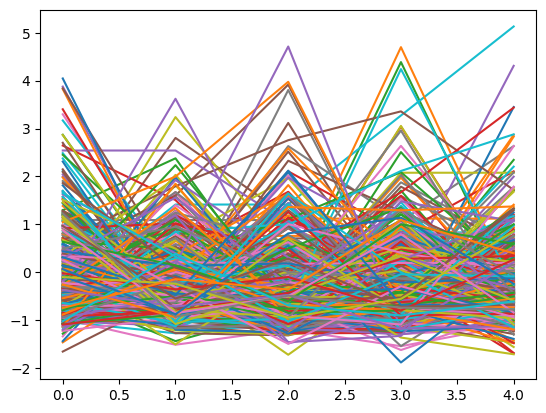

In [30]:
plt.plot(test[1][:5])